# Chinese world — per-polity vs per-CV-token comparison (chronological pairing).

## Configuration

In [1]:
from collections import defaultdict
import polars as pl
import duckdb

CULTURA_DB_PATH        = '../data/humans_clean.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'

## Connect

In [2]:
cultura_con        = duckdb.connect(CULTURA_DB_PATH,        read_only=True)
cross_verified_con = duckdb.connect(CROSS_VERIFIED_DB_PATH, read_only=True)

## Pairing of Cultura polities to Cross-Verified `string_citizenship_raw_d` tokens  (chronological)

In [3]:
# Curated pairing — Cliopatria polity ↔ Cross-Verified citizenship token(s).
# Each entry: (cliopatria_polity_or_None, [(cv_token, cv_historical_date_str_or_None), ...]).
# Empty list -> Cliopatria-only row (gap on CV side).
# cliopatria_polity = None -> CV-only row (gap on Cliopatria side).
# Order is chronological by polity start year.

CHINESE_PAIRS = [
    (None,                                              [('Xia_dynasty',                    None)]),
    ('Shang Dynasty',                                   [('Shang_dynasty',                  '-1599 to -1045')]),
    ('Zhou Dynasty',                                    [('Western_Zhou',                   '-1045 to -770'),
                                                          ('Zhou_dynasty',                   '-1045 to -255')]),
    ('Spring and Autumn States',                        []),
    ('Chu',                                             [('Chu',                            '-208 to -207')]),
    ('Qi',                                              []),
    ('Zheng',                                           []),
    ('Teng',                                            []),
    ('Wu',                                              [('Wu',                             '-280')]),
    ('Qin',                                             []),
    ('Later Zhou',                                      [('Later_Zhou_dynasty',             '951-960')]),
    ('Yue',                                             []),
    ('Warring States China',                            []),
    ('Zhao',                                            [('Zhao',                           '910-')]),
    ('Wei',                                             [('Wei',                            '-402 to -224')]),
    ('Han',                                             [('Han',                            '-220')]),
    ('Zhongshan',                                       []),
    ('Minyue',                                          []),
    ('Xiongnu',                                         [('Xiongnu',                        '-300 to 500')]),
    ('Qin Dynasty',                                     [('Qin_Dynasty',                    '-220 to -205')]),
    ('Zhai',                                            []),
    ('Nanyue',                                          [('Nanyue',                         '-203 to -110')]),
    ('Han Dynasty',                                     [('Han_Dynasty',                    '-205 to 220'),
                                                          ('Western_Han_Dynasty',            None),
                                                          ('Eastern_Han_Dynasty',            None)]),
    ('Great Yuan',                                      []),
    ('Goguryeo',                                        [('Goguryeo',                       '-36 to 668')]),
    ('Xin Dynasty',                                     [('Xin_dynasty',                    '9-23')]),
    ('Southern Xiongnu',                                []),
    ('Eastern Wu',                                      [('Eastern_Wu',                     '198-280')]),
    ('Cao Wei',                                         [('Cao_Wei',                        '220-265')]),
    ('Shu Han',                                         [('Shu_Han',                        '221-263')]),
    ('Yan Kingdom',                                     [('Yan',                            '237-238')]),
    ('Western Jin',                                     [('Western_Jin_dynasty',            '265-316'),
                                                          ('Jin_dynasty',                    '266-420'),
                                                          ('Jin_Dynasty',                    '266-420')]),
    ('Tuyuhun',                                         []),
    ('Former Zhao',                                     [('Han_Zhao',                       '304-329')]),
    ('Cheng Han',                                       [('Cheng_Han',                      '304-347')]),
    ('Eastern Jin',                                     [('Eastern_Jin_dynasty',            '317-420'),
                                                          ('Former_Liang',                   '320-376')]),
    ('Later Zhao',                                      []),
    ('Former Qin',                                      [('Former_Qin',                     '350-394')]),
    ('Later Qin',                                       [('Later_Qin',                      '384-417'),
                                                          ('Later_Yan',                      '384-409')]),
    ('Northern Wei',                                    [('Northern_Wei',                   '386-535')]),
    ('Western Qin',                                     []),
    ('Northern Liang',                                  []),
    ('Southern Liang',                                  [('Southern_Yan',                   '398-410')]),
    ('Western Liang',                                   [('Western_Liang',                  '400-421')]),
    ('Alliance between Northern Wei and Rouran Khaganate', []),
    ('Xia',                                             []),
    ('Liu Song Dynasty',                                [('Liu_Song_dynasty',               '420-479'),
                                                          ('Southern_Qi',                    '479-502')]),
    ('Liang Dynasty',                                   [('Liang_dynasty',                  '502-587')]),
    ('Eastern Wei',                                     [('Eastern_Wei',                    '534-550')]),
    ('Western Wei',                                     []),
    ('Northern Qi',                                     [('Northern_Qi',                    '550-577')]),
    ('Chen Dynasty',                                    [('Chen_dynasty',                   '557-589')]),
    ('Northern Zhou',                                   [('Northern_Zhou',                  '557-581')]),
    ('Sui Dynasty',                                     [('Sui_Dynasty',                    '581-618')]),
    ('Tang Dynasty',                                    [('Tang_dynasty',                   '618-907'),
                                                          ('Zhou_dynasty_(690–705)',         '690-705')]),
    ('Tibetan Empire',                                  [('Tibetan_Empire',                 '618-842')]),
    ('Balhae',                                          [('Balhae',                         '698-926')]),
    ('Nanzhao',                                         []),
    ('Tibetans',                                        []),
    ('Kara-Khanids',                                    [('Kara-Khanid_Khanate',            None)]),
    ('Qocho Kingdom',                                   []),
    ('Ganzhou Kingdom',                                 []),
    ('Kingdom of Khotan',                               []),
    ('Former Shu',                                      [('Former_Shu',                     '907-925')]),
    ('Later Liang Dynasty',                             [('Later_Liang_dynasty',            '907-923')]),
    ('Wuyue',                                           [('Wuyue',                          '907-978')]),
    ('Qi Kingdom',                                      []),
    ('Five Dynasties and Ten Kingdoms',                 []),
    ('Later Jin',                                       [('Later_Jin',                      None)]),
    ('Southern Han',                                    [('Southern_Han',                   '917-971')]),
    ('Southern Chu',                                    []),
    ('Liao Dynasty',                                    [('Liao_dynasty',                   '916-1125')]),
    ('Jingnan',                                         [('Jingnan',                        '924-963')]),
    ('Later Tang',                                      [('Later_Tang_Dynasty',             None)]),
    ('Later Shu',                                       []),
    ('Later Jin Dynasty',                               [('Later_Jin_Dynasty',              '936-947')]),
    ('Southern Tang',                                   [('Southern_Tang',                  '937-976')]),
    ('Later Han',                                       [('Later_Han_dynasty',              '947-951')]),
    ('Kingdom of Dali',                                 []),
    ('Northern Han',                                    []),
    ('Northern Song',                                   [('Northern_Song_Dynasty',          '960-1127'),
                                                          ('Song_Dynasty',                   '960-1279')]),
    ('Western Xia',                                     [('Western_Xia',                    '1038-1227')]),
    ('Southern Song',                                   [('Southern_Song_Dynasty',          '1127-1279')]),
    ('Eastern Kara-Khanids',                            []),
    ('Western Karakhanid Khanate',                      []),
    ('Mongol Empire',                                   [('Mongol_Empire',                  '1206-1368'),
                                                          ('Khamag_Mongol',                  '1120-1206')]),
    ('Vassalage of Western Xia to Great Jin',           []),
    ('Chagatai Khanate',                                [('Chagatai_Khanate',               '1225-1687')]),
    ('Yuan Dynasty',                                    [('Yuan_dynasty',                   '1271-1368')]),
    ('Allegiance of Chagatai Khanate to Yuan Dynasty',  []),
    ('Allegiance of Golden Horde to Yuan Dynasty',      []),
    ('Allegiance of Ilkhanate to Yuan Dynasty',         []),
    ('Moghulistan',                                     [('Moghulistan',                    '1347-1570')]),
    ('Tibet',                                           [('Tibet',                          None)]),
    ('Northern Yuan',                                   [('Northern_Yuan_Dynasty',          '1368-1691')]),
    ('Ming Dynasty',                                    [('Ming_dynasty',                   '1368-1644')]),
    ('East Turkestan',                                  [('First_East_Turkestan_Republic',  '1933-1934')]),
    ('Eastern Chagatai Khanate',                        []),
    ('Eastern Moghulistan',                             []),
    ('Western Moghulistan',                             []),
    (None,                                              [('Macau',                          '1557-')]),
    ('Khoshut Khanate',                                 [('Khoshut_Khanate',                '1650-1724')]),
    ('Dzungar Khanate',                                 [('Zunghar_Khanate',                None)]),
    ('Qing Dynasty',                                    [('Qing_dynasty',                   '1636-1912')]),
    ('Southern Ming',                                   [('Southern_Ming_Dynasty',          '1644-1661'),
                                                          ('Shun_Dynasty',                   '1644-1644')]),
    (None,                                              [('British_Hong_Kong',              '1841-1997')]),
    ('Taiping Heavenly Kingdom',                        [('Taiping_Heavenly_Kingdom',       '1851-1864')]),
    ('French Indochina',                                [('French_Indochina',               '1887-1954')]),
    ('Republic of China',                               [('Republic_of_China',              None),
                                                          ('Taiwan',                         '1912-'),
                                                          ('Taiwan_under_Japanese_rule',     '1895-1945'),
                                                          ('Beiyang_Government',             '1913-1928')]),
    ('Great Mongol State',                              []),
    ('Empire of China',                                 [('Empire_of_China',                '1915-1916')]),
    ('Kuomintang',                                      []),
    ('Chinese Communists',                              []),
    ('Anti-Kuomintang Coalition',                       []),
    (None,                                              [('Manchukuo',                      '1932-1945')]),
    ('Communist Party of China',                        []),
    ('East Turkestan Republic',                         [('Second_East_Turkestan_Republic', '1944-1946'),
                                                          ('Inner_Mongolia',                 '1947-')]),
    ("People's Republic of China",                      [("People's_Republic_of_China",     '1949-'),
                                                          ('China',                          None),
                                                          ('Tibet_Autonomous_Region',        '1965-'),
                                                          ('Hong_Kong',                      '1997-'),
                                                          ('Tibet_from_1912_to_1951',        None)]),
]

print(f'pairings        : {len(CHINESE_PAIRS)}')
print(f'paired (both)   : {sum(1 for p, t in CHINESE_PAIRS if p and t)}')
print(f'cliopatria-only : {sum(1 for p, t in CHINESE_PAIRS if p and not t)}')
print(f'cv-only         : {sum(1 for p, t in CHINESE_PAIRS if not p)}')

pairings        : 118
paired (both)   : 70
cliopatria-only : 44
cv-only         : 4


## Cultura — qids per Chinese polity

In [4]:
cliopatria_long = cultura_con.execute("""
    SELECT  wikidata_id, polity_name
    FROM    individuals_cliopatria
    WHERE   polity_name IS NOT NULL
""").pl().with_columns(
    pl.col('polity_name').str.split(';').alias('polity')
).explode('polity').with_columns(
    pl.col('polity').str.strip_chars()
).filter(pl.col('polity') != '')

polity_to_qids = {
    polity: set(qids)
    for polity, qids in cliopatria_long.group_by('polity').agg(pl.col('wikidata_id')).iter_rows()
}

print(f'distinct polities: {len(polity_to_qids):,}')

distinct polities: 1,335


## Cross-Verified — qids per `string_citizenship_raw_d` token

In [5]:
cv_raw_citizenship = cross_verified_con.execute("""
    SELECT  wikidata_code, string_citizenship_raw_d
    FROM    individuals
    WHERE   string_citizenship_raw_d IS NOT NULL
      AND   string_citizenship_raw_d != ''
""").pl()

TOKEN_JOINER = "'_'"

def tokenize_cv_citizenship(raw):
    raw = raw.strip()
    if raw.startswith("'") and raw.endswith("'"):
        raw = raw[1:-1]
    return [token for token in raw.split(TOKEN_JOINER) if token]

token_to_qids = defaultdict(set)
for qid, raw in zip(cv_raw_citizenship['wikidata_code'].to_list(),
                    cv_raw_citizenship['string_citizenship_raw_d'].to_list()):
    if not qid:
        continue
    for token in tokenize_cv_citizenship(raw):
        token_to_qids[token].add(qid)

print(f'distinct CV tokens: {len(token_to_qids):,}')

distinct CV tokens: 1,784


## Build the polity ↔ token comparison table

In [6]:
polity_token_rows = []
all_cultura_qids  = set()
all_cv_qids       = set()

for polity, pairings in CHINESE_PAIRS:
    cultura_qids_for_polity = polity_to_qids.get(polity, set()) if polity else set()
    if polity:
        all_cultura_qids |= cultura_qids_for_polity

    if not pairings:
        polity_token_rows.append({
            'cultura_polity':  polity or '',
            'cultura_n':       len(cultura_qids_for_polity) if polity else None,
            'cv_token':        '',
            'cv_n':            None,
        })
        continue

    for index, (token, _cv_date) in enumerate(pairings):
        cv_qids_for_token = token_to_qids.get(token, set())
        all_cv_qids |= cv_qids_for_token
        polity_token_rows.append({
            'cultura_polity':  (polity if polity else '') if index == 0 else '',
            'cultura_n':       (len(cultura_qids_for_polity) if polity else None) if index == 0 else None,
            'cv_token':        token,
            'cv_n':            len(cv_qids_for_token),
        })

polity_token_table = pl.DataFrame(polity_token_rows)
print('shape:', polity_token_table.shape)
with pl.Config(tbl_rows=20, tbl_cols=-1, tbl_width_chars=200, fmt_str_lengths=80):
    print(polity_token_table.head(20))

shape: (138, 4)
shape: (20, 4)
┌──────────────────────────┬───────────┬────────────────────┬──────┐
│ cultura_polity           ┆ cultura_n ┆ cv_token           ┆ cv_n │
│ ---                      ┆ ---       ┆ ---                ┆ ---  │
│ str                      ┆ i64       ┆ str                ┆ i64  │
╞══════════════════════════╪═══════════╪════════════════════╪══════╡
│                          ┆ null      ┆ Xia_dynasty        ┆ 13   │
│ Shang Dynasty            ┆ 8         ┆ Shang_dynasty      ┆ 6    │
│ Zhou Dynasty             ┆ 11        ┆ Western_Zhou       ┆ 2    │
│                          ┆ null      ┆ Zhou_dynasty       ┆ 4    │
│ Spring and Autumn States ┆ 0         ┆                    ┆ null │
│ Chu                      ┆ 83        ┆ Chu                ┆ 5    │
│ Qi                       ┆ 39        ┆                    ┆ null │
│ Zheng                    ┆ 0         ┆                    ┆ null │
│ Teng                     ┆ 1         ┆                    ┆ null │
│ W

## Polity-token totals  (union counts and overlap)

In [7]:
polity_token_totals = pl.DataFrame({
    'metric': [
        'unique Cultura individuals (union of polity rows)',
        'unique Cross-Verified individuals (union of token rows)',
        'Q-id overlap',
        'Cultura only',
        'Cross-Verified only',
    ],
    'individuals': [
        len(all_cultura_qids),
        len(all_cv_qids),
        len(all_cultura_qids & all_cv_qids),
        len(all_cultura_qids - all_cv_qids),
        len(all_cv_qids - all_cultura_qids),
    ],
})

print('shape:', polity_token_totals.shape)
polity_token_totals

shape: (5, 2)


metric,individuals
str,i64
"""unique Cultura individuals (un…",169846
"""unique Cross-Verified individu…",17627
"""Q-id overlap""",15576
"""Cultura only""",154270
"""Cross-Verified only""",2051


## Paper-ready summary table  (LaTeX-style booktabs)

Pairing of every Cliopatria Chinese polity with its Cross-Verified `string_citizenship_raw_d` token(s), in chronological order, with both Cliopatria date ranges (from `polities_periods_cliopatria`) and curated CV historical date ranges. Cliopatria-side counts come from `polities_cliopatria.number_individuals`. Empty cells flag gaps: a polity present in Cliopatria but absent from CV (CV side blank), or a CV token without a matching Cliopatria polity (Cliopatria side blank). Split into four chronological panels for the paper.

In [8]:
import os
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times', 'STIX', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
})

# --- date / count lookups -----------------------------------------------------

period_df = cultura_con.execute("""
    SELECT  polity_name,
            MIN(from_year) AS from_y,
            MAX(to_year)   AS to_y
    FROM    polities_periods_cliopatria
    GROUP   BY polity_name
""").pl()
period_lookup = {r['polity_name']: (r['from_y'], r['to_y']) for r in period_df.to_dicts()}

count_df = cultura_con.execute("""
    SELECT name, number_individuals FROM polities_cliopatria
""").pl()
count_lookup = {r['name']: r['number_individuals'] for r in count_df.to_dicts()}

# --- formatting helpers -------------------------------------------------------

def fmt_year_int(y):
    return f'{-y} BCE' if y < 0 else f'{y}'

def fmt_period_int(polity):
    pair = period_lookup.get(polity)
    if not pair or pair[0] is None or pair[1] is None:
        return ''
    return f'{fmt_year_int(pair[0])}–{fmt_year_int(pair[1])}'

def _y(s):
    return f'{s[1:]} BCE' if s.startswith('-') else s

def fmt_period_str(s):
    """Normalise a curated CV date string ('-1599 to -1045', '951-960', '1557-', '-280')."""
    if not s:
        return ''
    s = s.strip().strip('()').strip()
    if ' to ' in s:
        a, b = s.split(' to ')
    elif s.endswith('-'):
        return _y(s[:-1].strip()) + '–'
    elif s.startswith('-') and s.count('-') == 1:
        return _y(s)
    else:
        idx = s.find('-', 1)
        if idx == -1:
            return _y(s)
        a, b = s[:idx], s[idx + 1:]
    a, b = a.strip(), b.strip()
    if not b:
        return _y(a) + '–'
    if not a:
        return '–' + _y(b)
    ai, bi = int(a), int(b)
    if ai < 0 and bi < 0:
        return f'{-ai}–{-bi} BCE'
    if ai < 0:
        return f'{-ai} BCE – {bi} CE'
    return f'{ai}–{bi}'

def fmt_n(n):
    return '' if n is None else f'{n:,}'

def cu_sort_key(polity, pairings):
    """Chronological sort key — Cultura start year if present, else CV start year, else None."""
    if polity:
        p = period_lookup.get(polity)
        if p and p[0] is not None:
            return p[0]
    for _tk, dt in pairings:
        if dt:
            d = dt.strip().strip('()').strip()
            if ' to ' in d:
                d = d.split(' to ')[0]
            elif d.endswith('-'):
                d = d[:-1]
            else:
                idx = d.find('-', 1)
                if idx != -1:
                    d = d[:idx]
            try:
                return int(d.strip())
            except ValueError:
                continue
    return None

# --- expand pairings into one flat list of rows -------------------------------

flat_rows = []
for polity, pairings in CHINESE_PAIRS:
    cu_period = fmt_period_int(polity) if polity else ''
    cu_n      = fmt_n(count_lookup.get(polity)) if polity else ''
    cu_label  = polity if polity else ''
    sk        = cu_sort_key(polity, pairings)

    if not pairings:
        flat_rows.append({
            'cu_polity':  cu_label,
            'cu_period':  cu_period,
            'cu_n':       cu_n,
            'cv_token':   '',
            'cv_period':  '',
            'cv_n':       '',
            'sort_key':   sk,
        })
        continue

    for i, (token, cv_date_str) in enumerate(pairings):
        cv_n_int = len(token_to_qids.get(token, set()))
        flat_rows.append({
            'cu_polity':  cu_label   if i == 0 else '',
            'cu_period':  cu_period  if i == 0 else '',
            'cu_n':       cu_n       if i == 0 else '',
            'cv_token':   token.replace('_', ' '),
            'cv_period':  fmt_period_str(cv_date_str),
            'cv_n':       fmt_n(cv_n_int) if cv_n_int > 0 else '0',
            'sort_key':   sk if i == 0 else None,
        })

# --- chronological splits (4 panels) ------------------------------------------
# Breakpoints by start year: 220 (end of Han), 618 (Tang), 1368 (Ming).

def split_panels(rows, breakpoints):
    panels = [[] for _ in range(len(breakpoints) + 1)]
    last_key = -10000   # anything pre-Shang and undated lands in panel (a)
    for r in rows:
        if r['sort_key'] is not None:
            last_key = r['sort_key']
        idx = next((i for i, bp in enumerate(breakpoints) if last_key < bp), len(breakpoints))
        panels[idx].append(r)
    return panels

panel_a, panel_b, panel_c, panel_d = split_panels(flat_rows, [220, 618, 1368])

print(f'panel A (pre-Han end)        : {len(panel_a)} rows')
print(f'panel B (Three Kingdoms-Sui) : {len(panel_b)} rows')
print(f'panel C (Tang–Yuan)          : {len(panel_c)} rows')
print(f'panel D (Ming–PRC)           : {len(panel_d)} rows')

# --- subtotal helper ----------------------------------------------------------

def make_subtotal(rows, label):
    cu_total = sum(int(r['cu_n'].replace(',', '')) for r in rows if r['cu_n'])
    cv_total = sum(int(r['cv_n'].replace(',', '')) for r in rows if r['cv_n'])
    return {
        'cu_polity':  label,
        'cu_period':  '',
        'cu_n':       f'{cu_total:,}',
        'cv_token':   '',
        'cv_period':  '',
        'cv_n':       f'{cv_total:,}',
    }

# --- 6-column booktabs renderer -----------------------------------------------

def render_pair_table(body_rows, total_row, panel_label, figsize, save_path):
    headers   = ['Cliopatria polity', 'Cliopatria dates', 'Cultura n',
                 'CV citizenship token', 'CV dates', 'CV n']
    col_x     = [0.005, 0.300, 0.460, 0.575, 0.835, 0.995]
    col_align = ['left', 'left', 'right', 'left',  'left',  'right']

    fig = plt.figure(figsize=figsize, facecolor='white')
    ax  = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    n_body  = len(body_rows)
    n_lines = n_body + 1 + (1 if total_row else 0)
    top, bottom = 0.93, 0.04
    row_h   = (top - bottom) / n_lines
    fs_body = 14
    fs_head = 15

    ax.hlines(top, 0, 1, lw=2.0, color='black')

    hy = top - row_h * 0.55
    for h, x, a in zip(headers, col_x, col_align):
        ax.text(x, hy, h, ha=a, va='center',
                fontsize=fs_head, fontweight='bold')

    body_top = top - row_h
    ax.hlines(body_top, 0, 1, lw=0.7, color='black')

    fields = ['cu_polity', 'cu_period', 'cu_n', 'cv_token', 'cv_period', 'cv_n']
    for i, r in enumerate(body_rows):
        y = body_top - row_h * (i + 0.55)
        for f, x, a in zip(fields, col_x, col_align):
            ax.text(x, y, r[f], ha=a, va='center', fontsize=fs_body)

    body_bot = body_top - row_h * n_body

    if total_row is not None:
        ax.hlines(body_bot, 0, 1, lw=0.7, color='black')
        ty = body_bot - row_h * 0.55
        for f, x, a in zip(fields, col_x, col_align):
            ax.text(x, ty, total_row[f], ha=a, va='center',
                    fontsize=fs_body, fontweight='bold')
        end_y = body_bot - row_h
    else:
        end_y = body_bot

    ax.hlines(end_y, 0, 1, lw=2.0, color='black')

    fig.text(0.005, 0.985, panel_label,
             fontsize=fs_head + 3, fontweight='bold', va='top', ha='left')

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, facecolor='white')
    plt.show()

pl.DataFrame(flat_rows).drop('sort_key')

panel A (pre-Han end)        : 31 rows
panel B (Three Kingdoms-Sui) : 30 rows
panel C (Tang–Yuan)          : 42 rows
panel D (Ming–PRC)           : 35 rows


cu_polity,cu_period,cu_n,cv_token,cv_period,cv_n
str,str,str,str,str,str
"""""","""""","""""","""Xia dynasty""","""""","""13"""
"""Shang Dynasty""","""1600 BCE–1001 BCE""","""30""","""Shang dynasty""","""1599–1045 BCE""","""6"""
"""Zhou Dynasty""","""1000 BCE–751 BCE""","""53""","""Western Zhou""","""1045–770 BCE""","""2"""
"""""","""""","""""","""Zhou dynasty""","""1045–255 BCE""","""4"""
"""Spring and Autumn States""","""750 BCE–481 BCE""","""135""","""""","""""",""""""
…,…,…,…,…,…
"""People's Republic of China""","""1950–2024""","""74,150""","""People's Republic of China""","""1949–""","""12,360"""
"""""","""""","""""","""China""","""""","""1,274"""
"""""","""""","""""","""Tibet Autonomous Region""","""1965–""","""3"""


### Table 1a — Pre-imperial through end of Han  (start year < 220 CE)

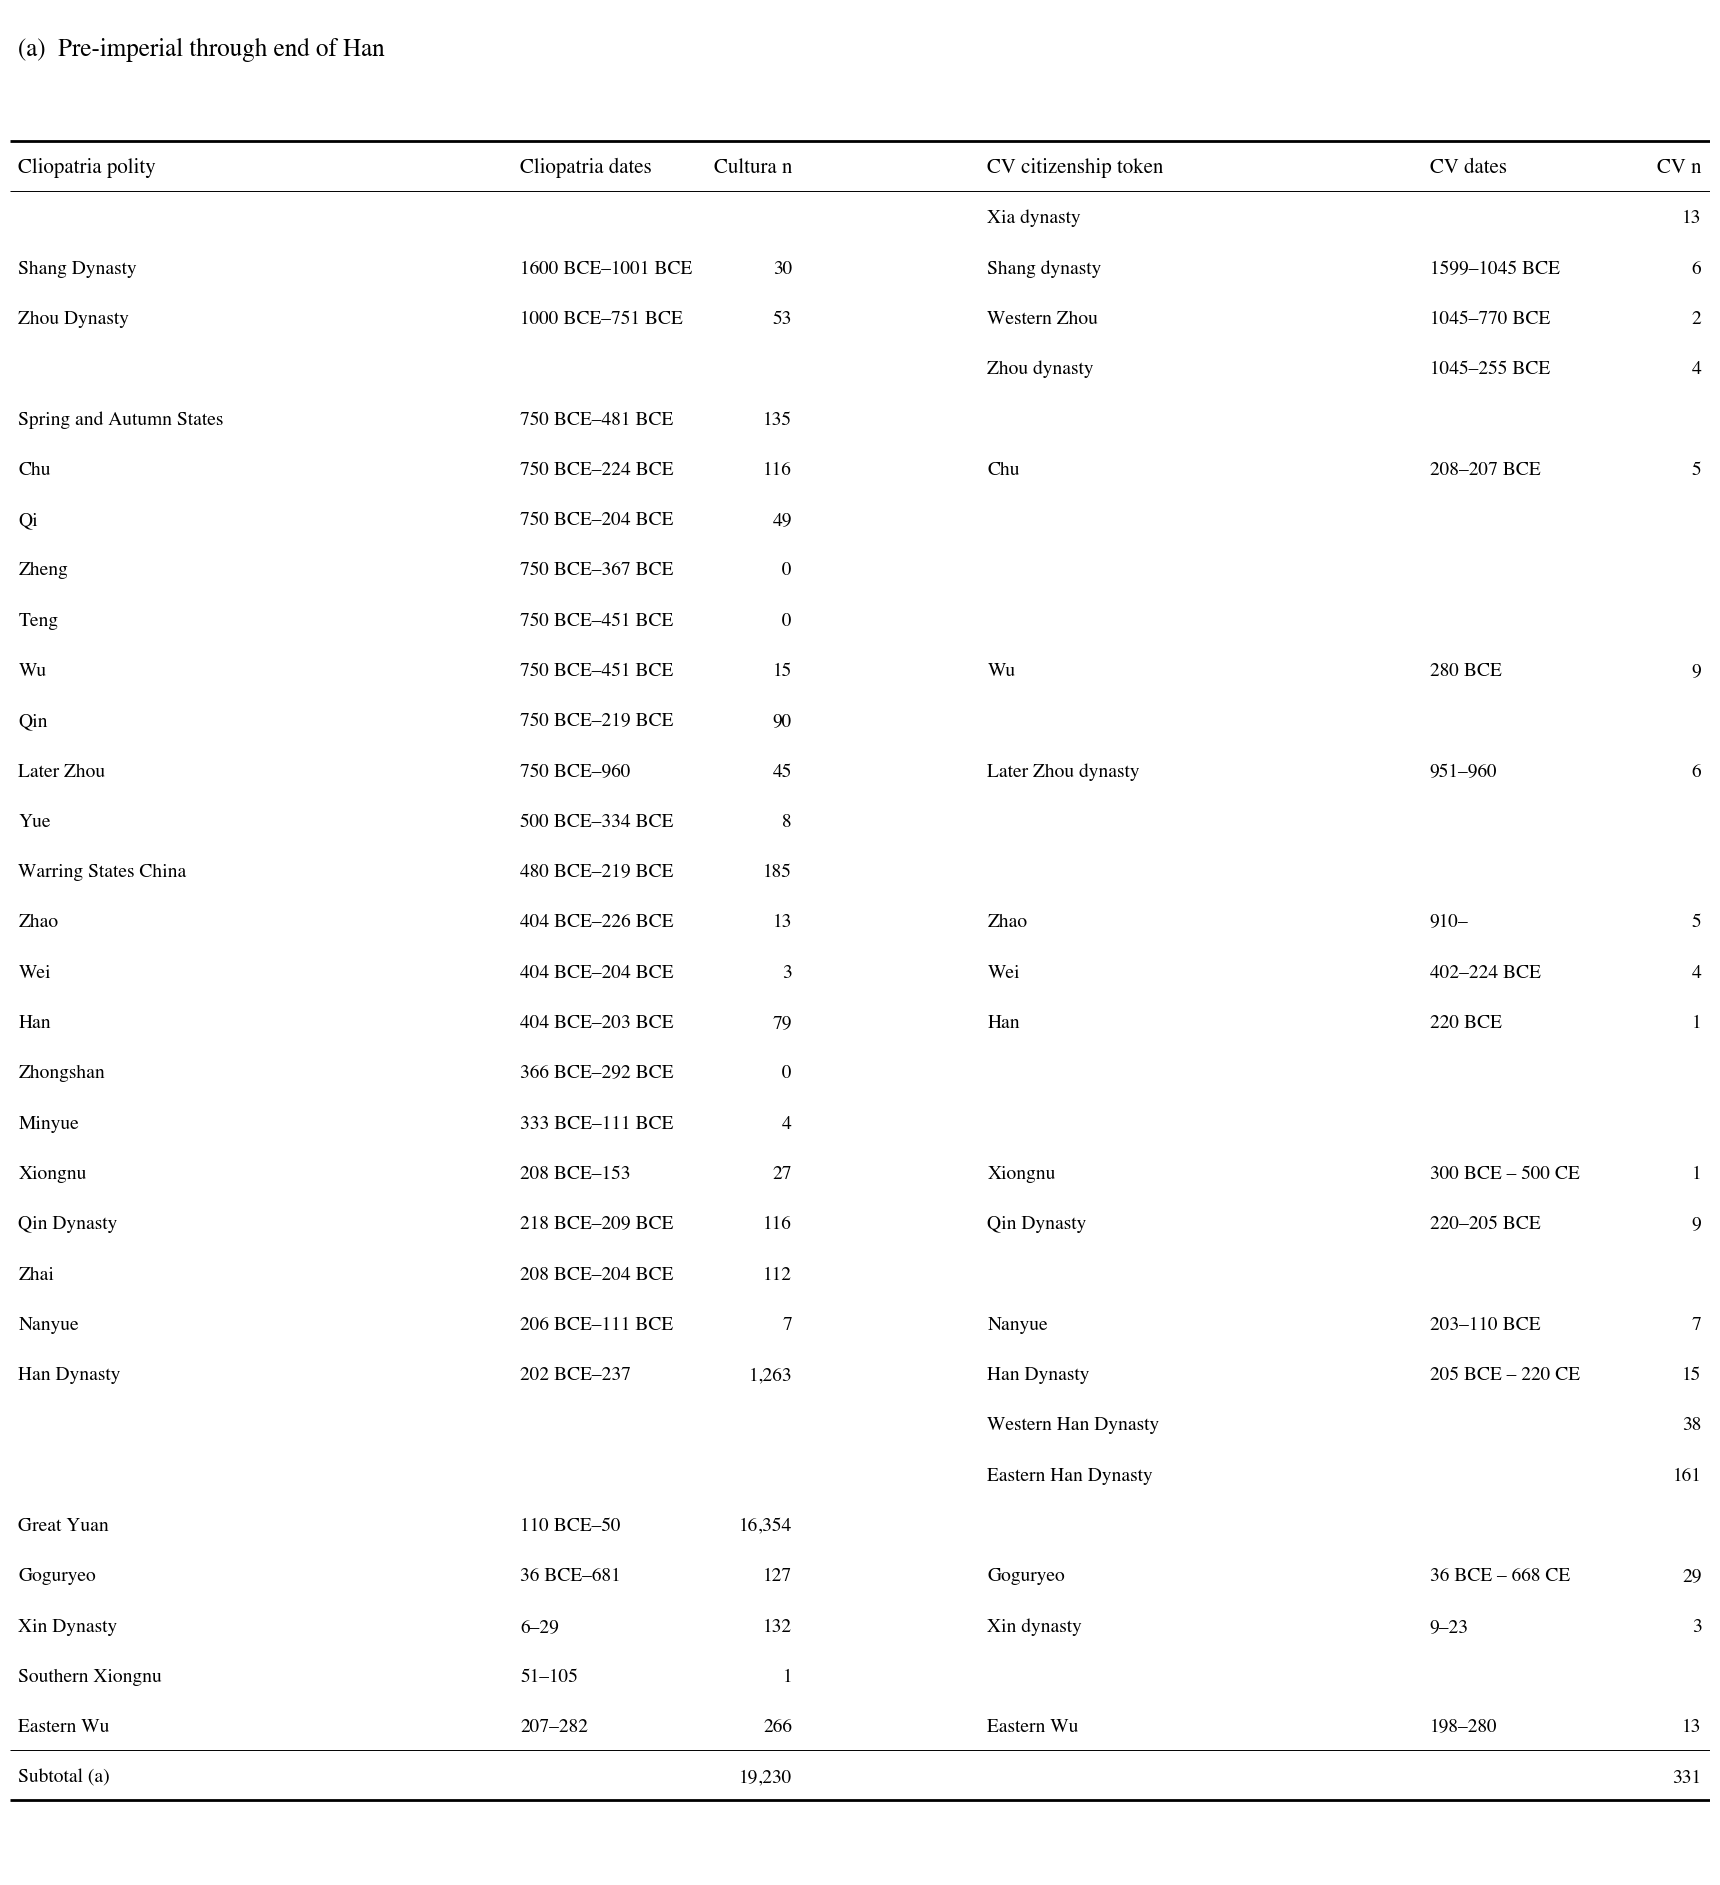

In [9]:
render_pair_table(
    panel_a,
    total_row=make_subtotal(panel_a, 'Subtotal (a)'),
    panel_label='(a)  Pre-imperial through end of Han',
    figsize=(17, 0.55 * (len(panel_a) + 2) + 0.5),
    save_path='../paper/table_chinese_dynasties_a.png',
)

### Table 1b — Three Kingdoms through Sui  (220–617 CE)

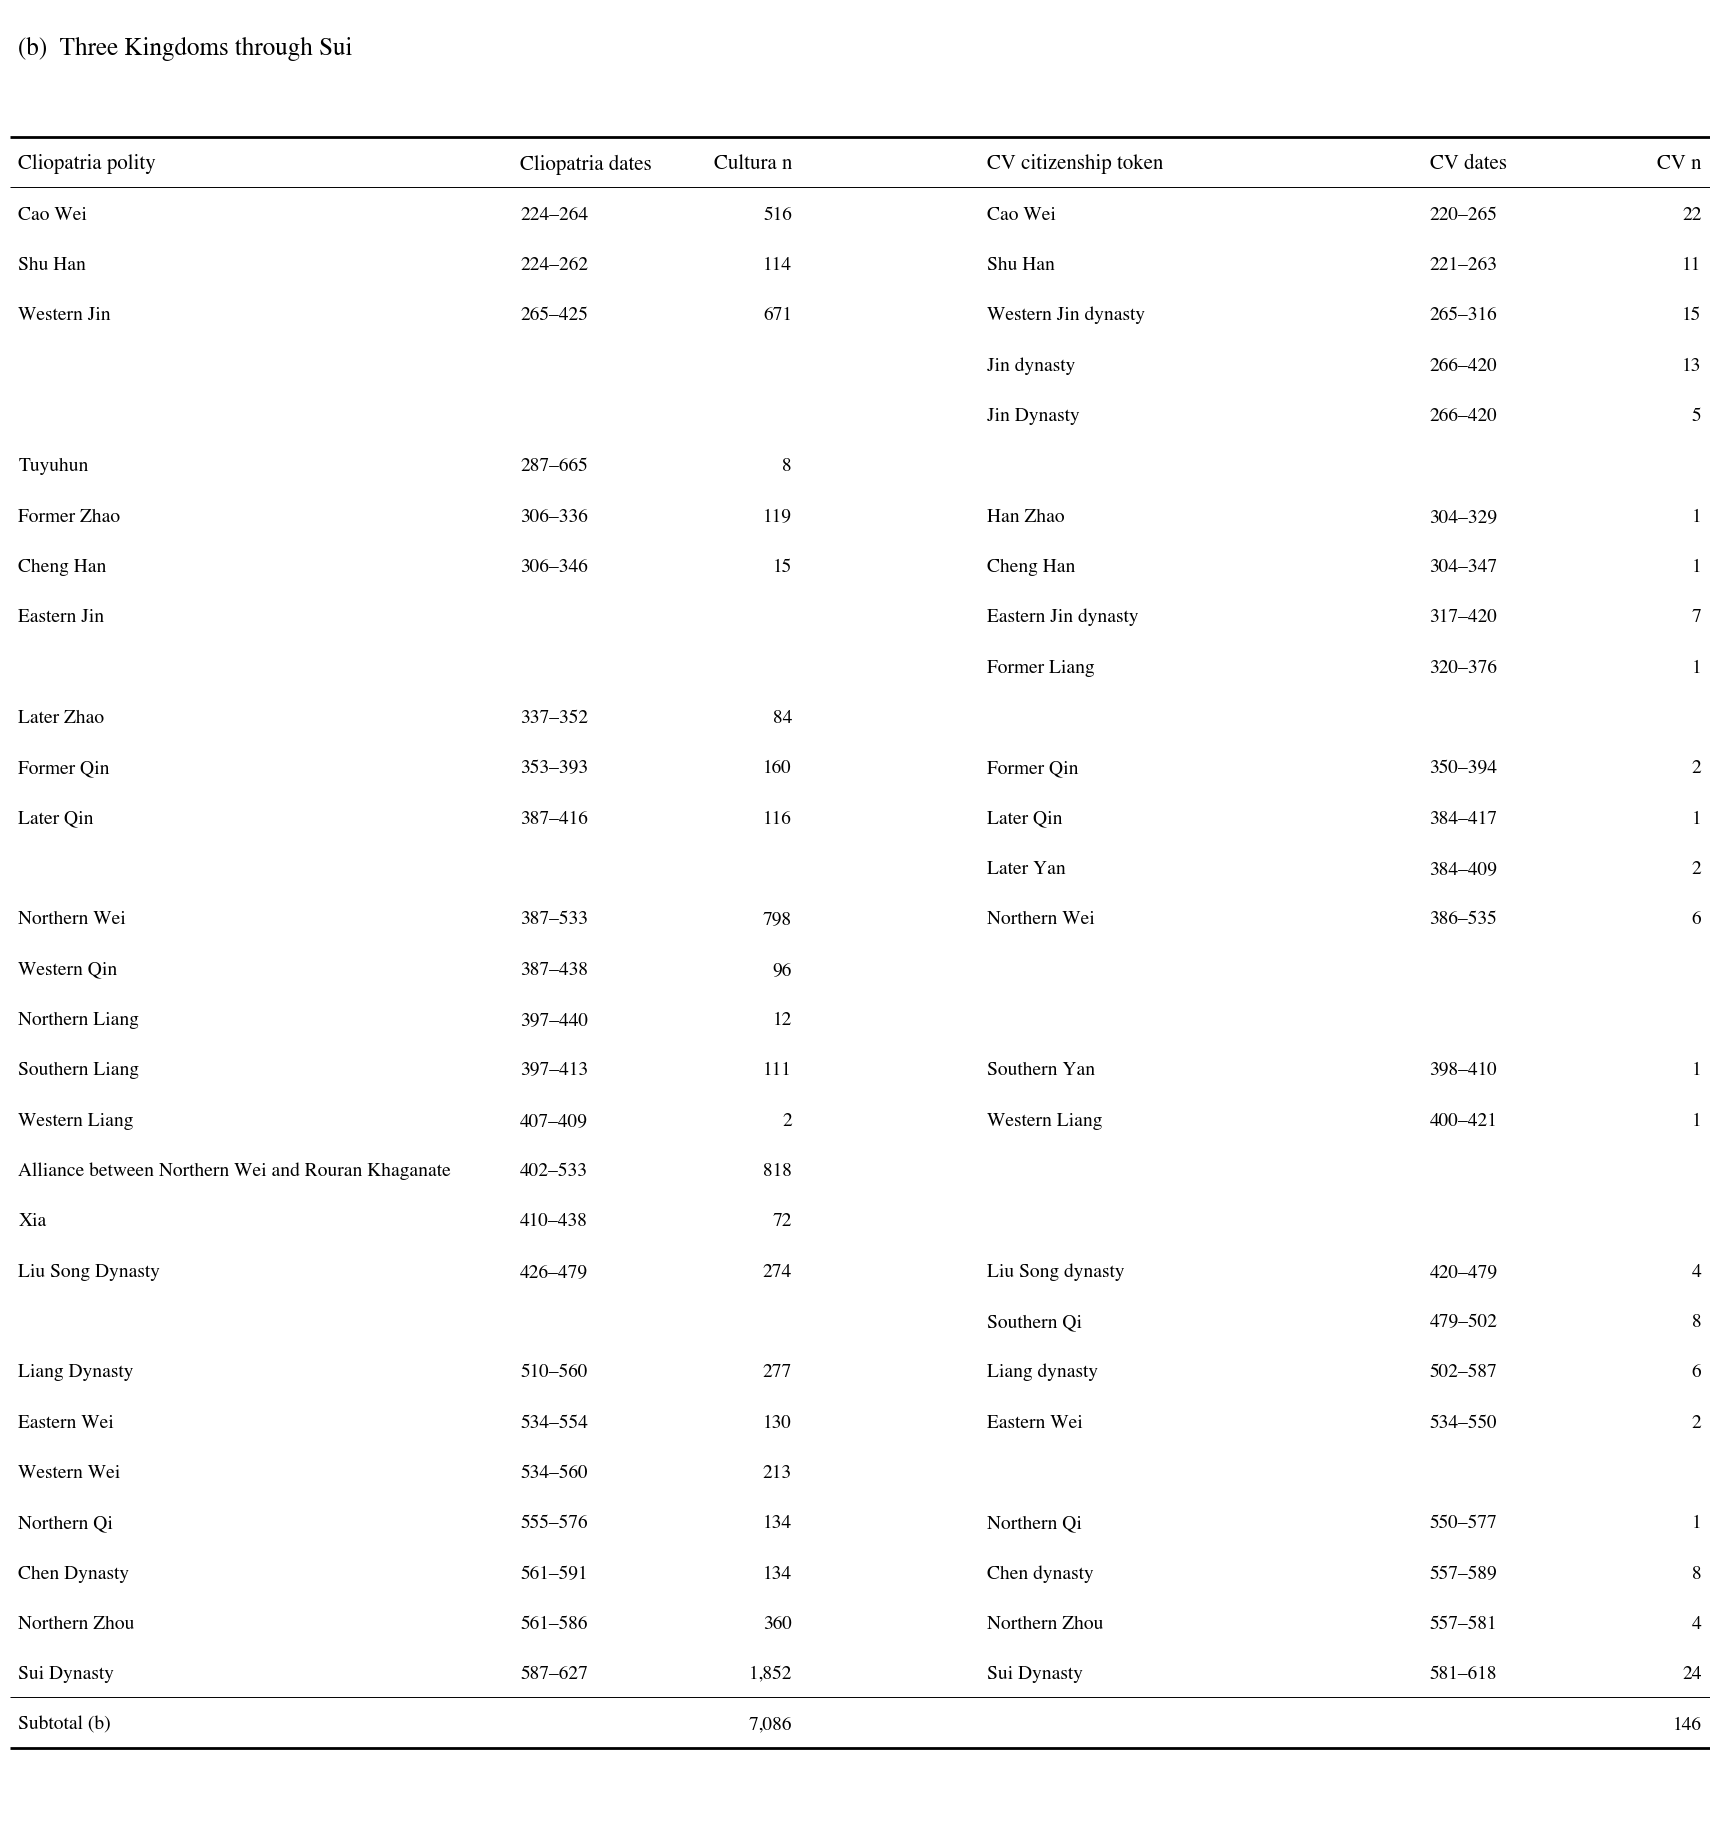

In [10]:
render_pair_table(
    panel_b,
    total_row=make_subtotal(panel_b, 'Subtotal (b)'),
    panel_label='(b)  Three Kingdoms through Sui',
    figsize=(17, 0.55 * (len(panel_b) + 2) + 0.5),
    save_path='../paper/table_chinese_dynasties_b.png',
)

### Table 1c — Tang through Yuan  (618–1367 CE)

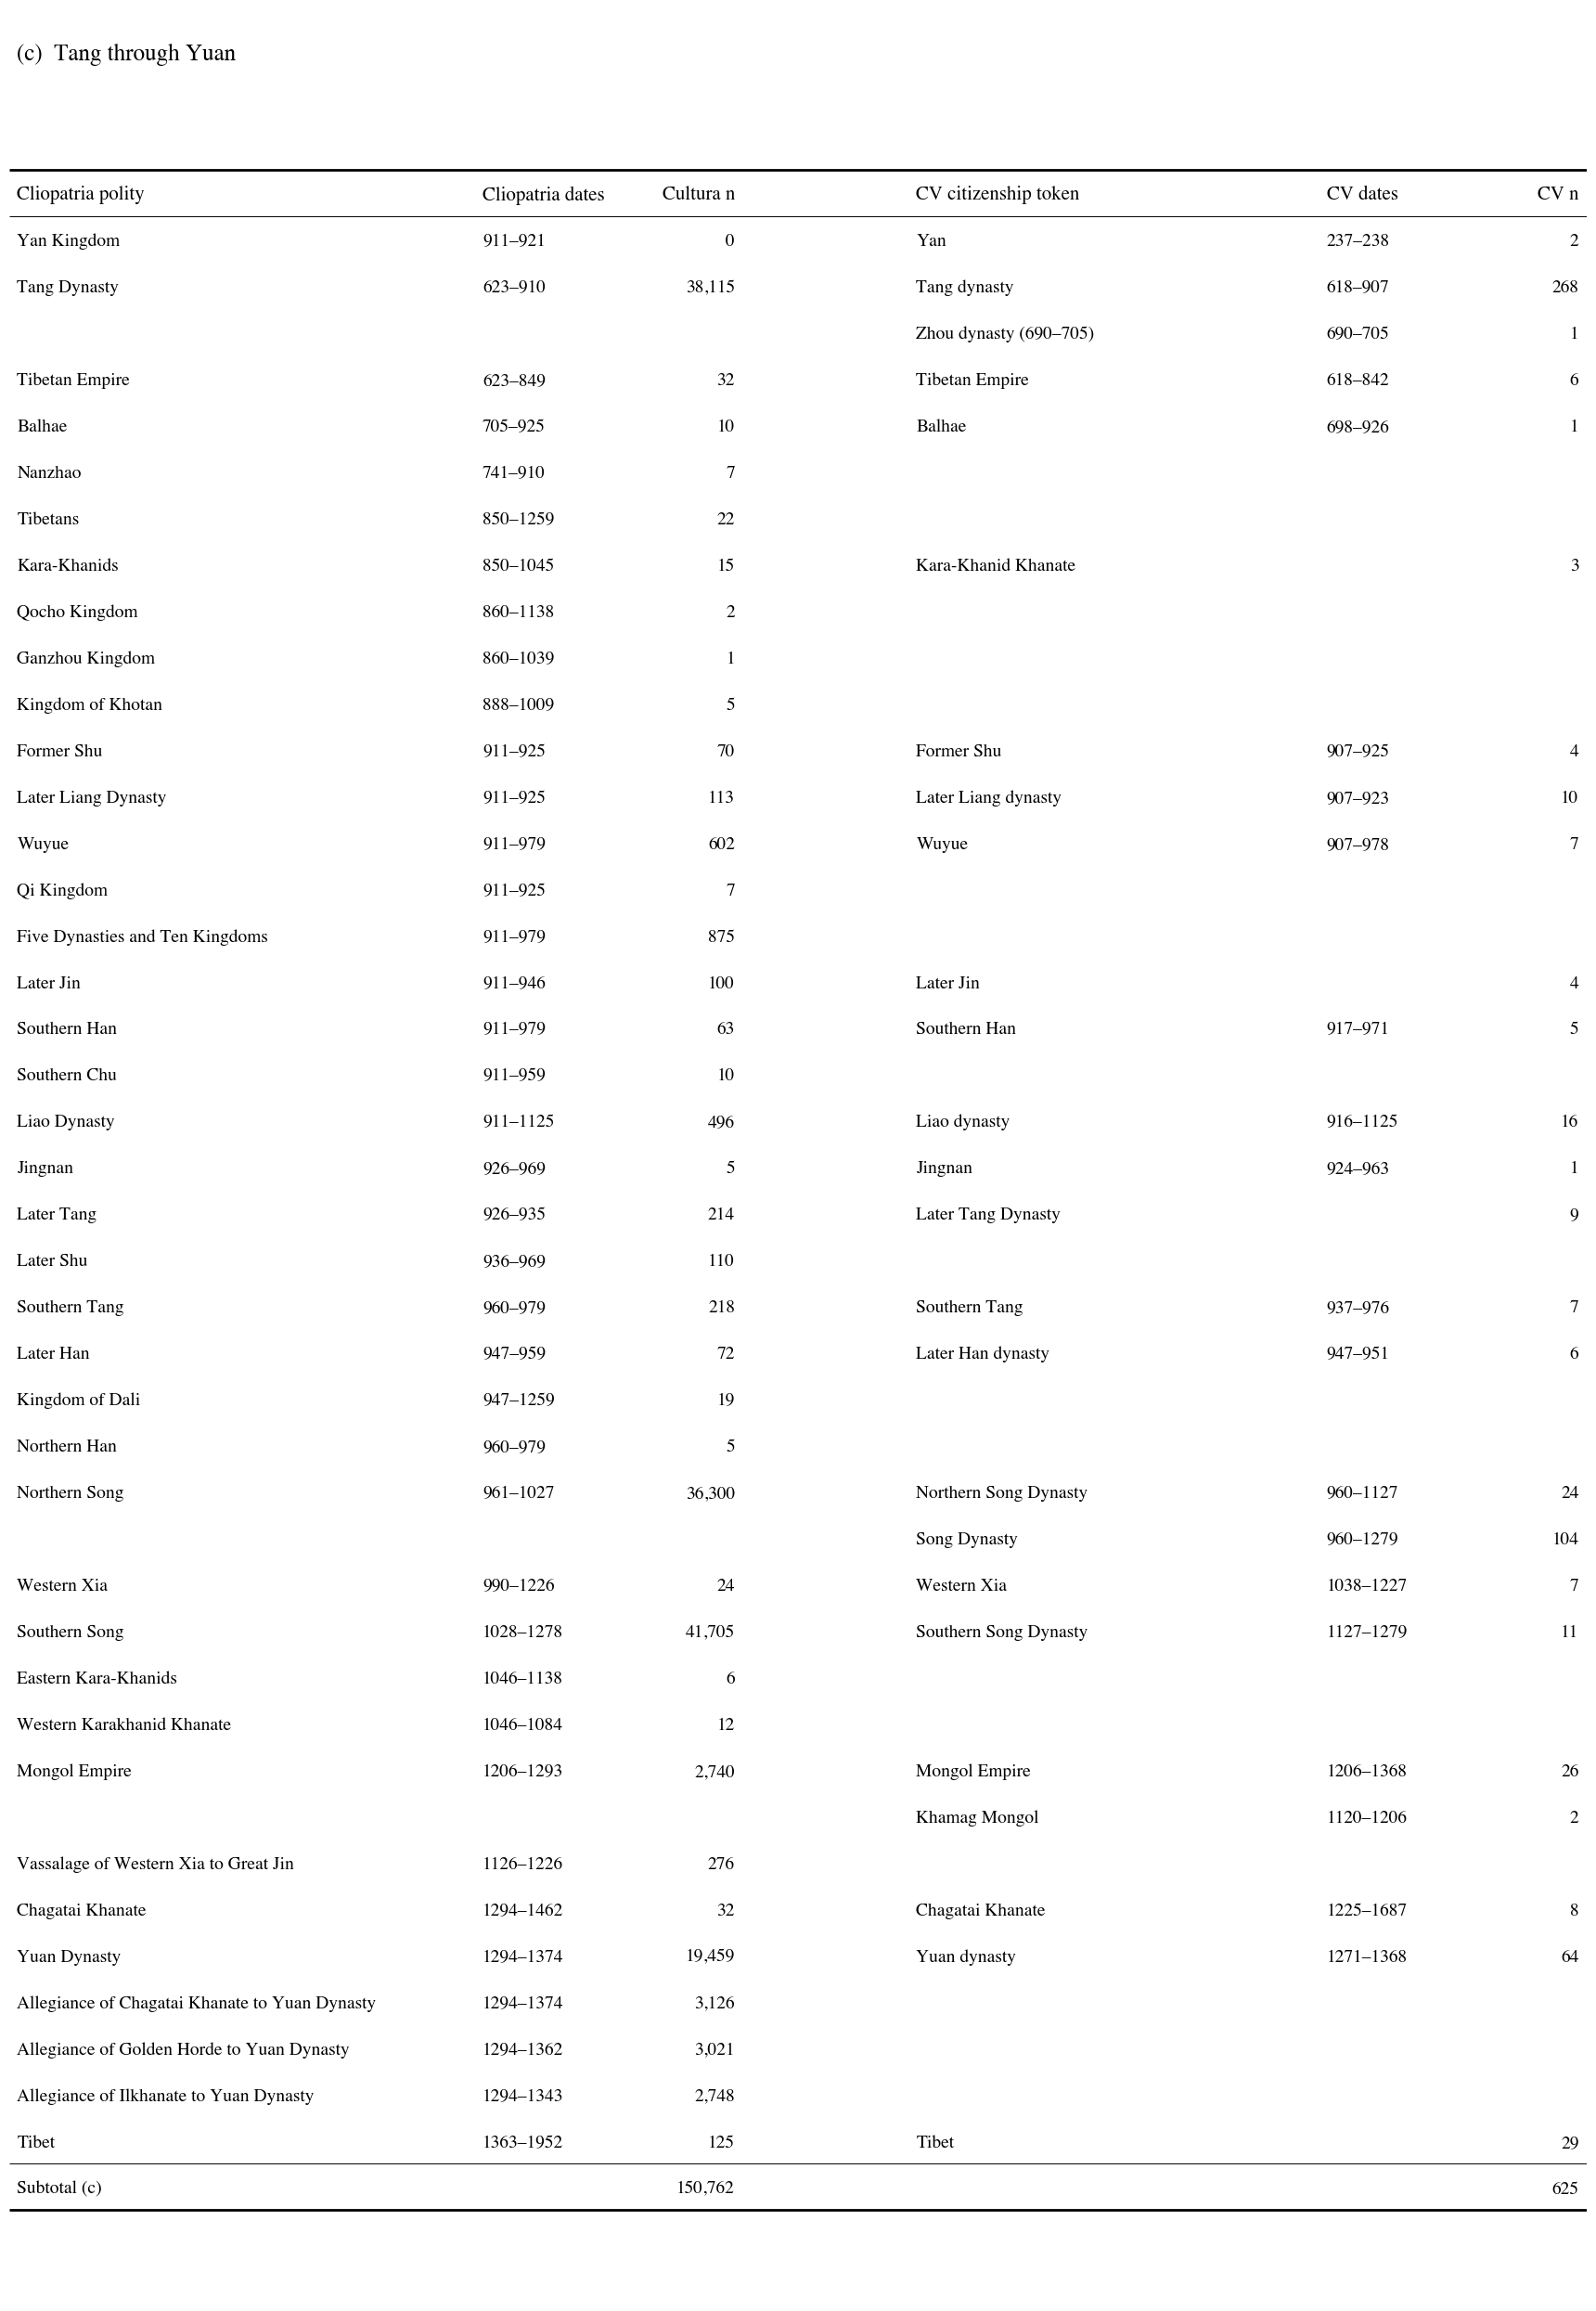

In [11]:
render_pair_table(
    panel_c,
    total_row=make_subtotal(panel_c, 'Subtotal (c)'),
    panel_label='(c)  Tang through Yuan',
    figsize=(17, 0.55 * (len(panel_c) + 2) + 0.5),
    save_path='../paper/table_chinese_dynasties_c.png',
)

### Table 1d — Ming through People's Republic of China  (1368–present)

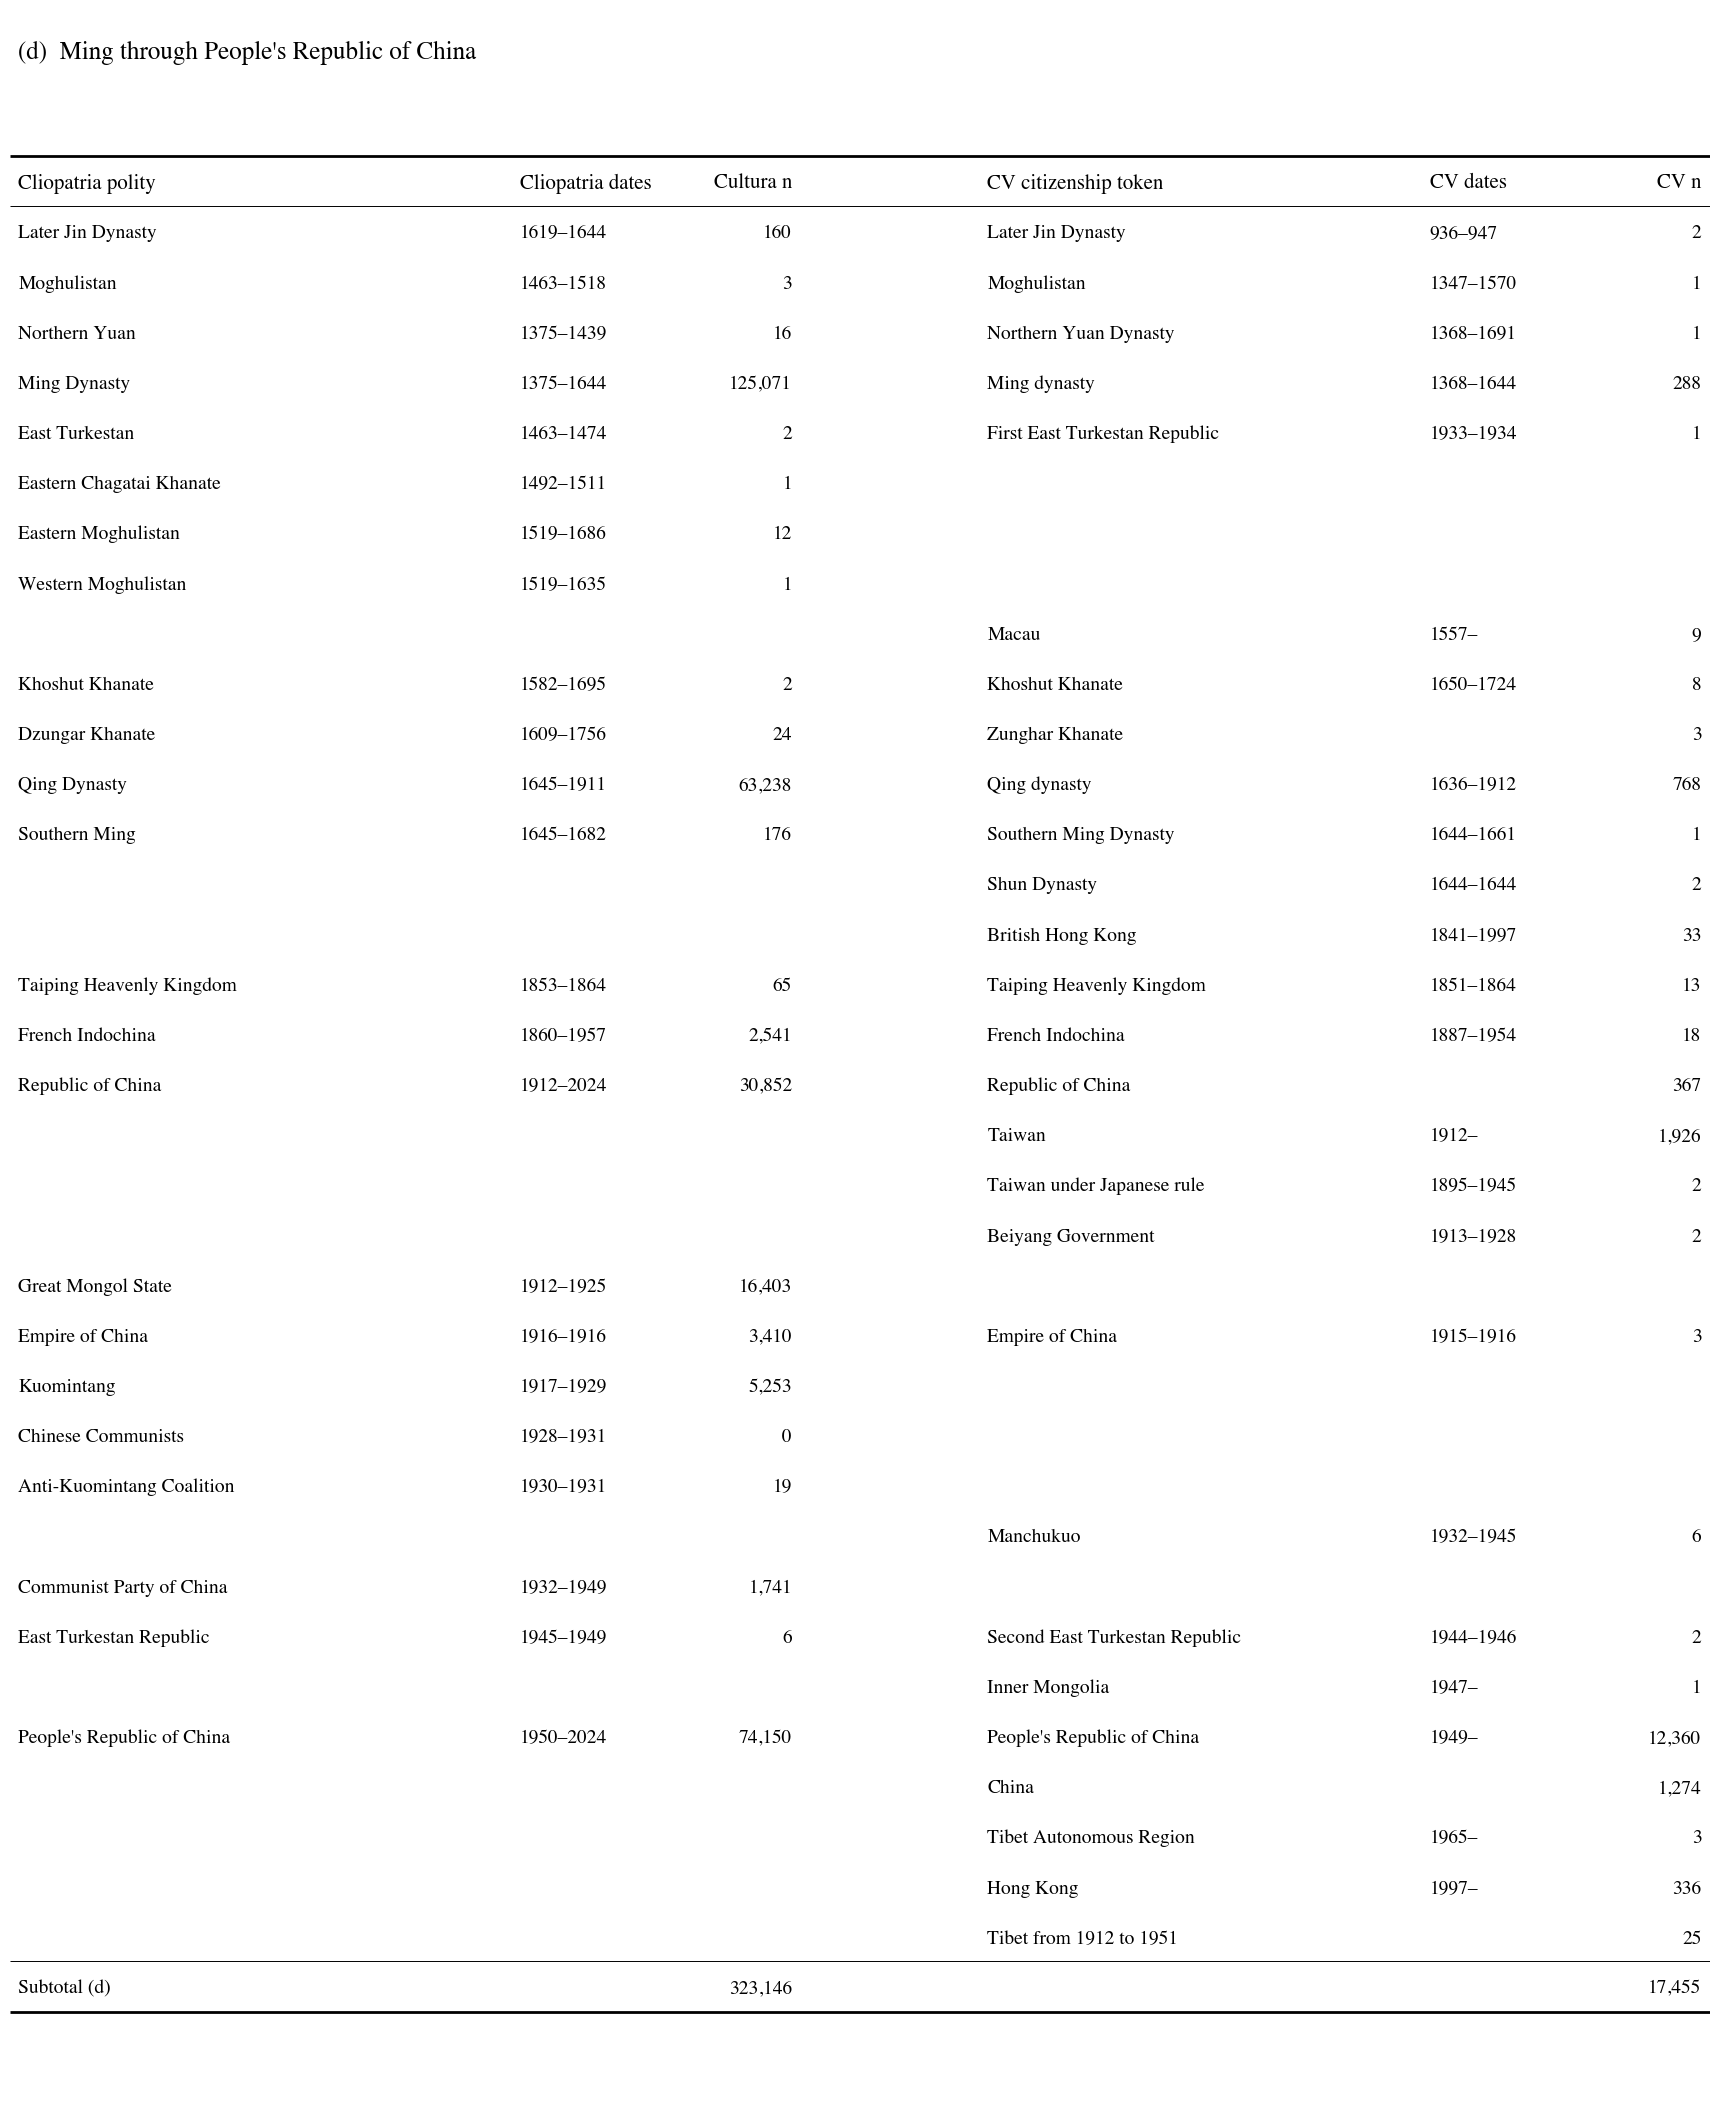

In [12]:
render_pair_table(
    panel_d,
    total_row=make_subtotal(panel_d, 'Subtotal (d)'),
    panel_label="(d)  Ming through People's Republic of China",
    figsize=(17, 0.55 * (len(panel_d) + 2) + 0.5),
    save_path='../paper/table_chinese_dynasties_d.png',
)

## Close connections

In [13]:
cultura_con.close()
cross_verified_con.close()